# Model Training & Development Notebook

Run these cells in order. Each cell builds on the previous one — if you
edit `src/` files, just re-run the relevant cell (Jupyter keeps state in
memory, so you don't need to re-run everything unless you change something
upstream).

**Kernel**: make sure this notebook is using your project's `.venv` Python
interpreter (VS Code will usually prompt you to select it, or use the
kernel picker in the top right).

In [5]:
import os

# Jupyter/VS Code often launches notebooks with the notebook's own folder
# as the working directory. Force it back to the project root so relative
# paths in config.yaml (e.g. "data/raw/...") resolve correctly everywhere.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory is now:", os.getcwd())

Working directory is now: /home/ionicx/Vantara-churning-prediction-model


In [6]:
import sys
sys.path.insert(0, '..')  # so `src.` imports work from notebooks/ folder

import pandas as pd
import numpy as np

from src.utils.config import load_config
from src.data.load import load_raw_transactions
from src.data.clean import run_cleaning_pipeline
from src.data.validate import run_validation
from src.features.build_features import build_customer_feature_table
from src.features.preprocessing import stratified_split, get_feature_columns, fit_scaler, apply_scaler

pd.set_option('display.max_columns', None)

## 1. Load, validate, clean (skip if already cached)

In [7]:
cfg = load_config('config/config.yaml')
raw = load_raw_transactions(cfg['paths']['raw_data'], cfg['sheets'])
print('raw shape:', raw.shape)

result = run_validation(raw, cfg)
print('validation passed:', result.passed, result.errors)

cleaned = run_cleaning_pipeline(raw, cfg['cleaning']['non_product_stockcodes'], cfg['cleaning']['outlier_iqr_multiplier'])
cleaned.to_parquet('data/interim/cleaned_transactions.parquet')
print('cleaned shape:', cleaned.shape, '| dupes removed:', cleaned.attrs['n_duplicates_removed'])

raw shape: (1067371, 9)
validation passed: True []
cleaned shape: (1033034, 15) | dupes removed: 34337


## 2. Build the customer feature table

In [11]:
cutoff = cleaned['invoice_date'].max() - pd.Timedelta(days=90)
feats = build_customer_feature_table(cleaned, cutoff, churn_window_days=90)
#feats.to_parquet('/data/processed/customer_features.parquet')
feats.to_parquet('data/processed/customer_features.parquet')
print('feature table shape:', feats.shape)
print(feats['churned'].value_counts(normalize=True).round(3))
feats.head()

feature table shape: (5301, 24)
churned
1    0.562
0    0.438
Name: proportion, dtype: float64


,customer_id,recency_days,frequency,monetary_total,monetary_avg,historical_clv,avg_basket_size,purchase_trend_slope,purchase_interval_variance,seasonal_concentration,affinity_20685,affinity_22386,affinity_22423,affinity_22502,affinity_47566,affinity_48138,affinity_84879,affinity_85099B,affinity_85099F,affinity_85123A,return_rate,discount_sensitivity,engagement_score,churned
0,12346,235,15,264.86,7.158378,264.86,2.466667,-1.486014e-01,1922.642857,0.485648,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.081081,0.351351,49.806640,1
1,12347,39,6,3402.39,20.74628,3402.39,27.333333,3.929795e-17,162.800000,0.172756,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.786585,77.497642,0
2,12348,158,4,1388.4,31.554545,1388.4,11.000000,-2.633341e-17,457.000000,0.320142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,57.316544,0
3,12349,317,3,2196.99,20.923714,2196.99,35.000000,-1.525991e-17,612.500000,0.511906,0.713983,0.0,0.0,0.0,0.0,0.0,0.286017,0.0,0.0,0.0,0.047619,0.761905,48.268251,0
4,12350,219,1,294.4,18.4,294.4,16.000000,0.000000e+00,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.875000,28.247500,1


## 3. Quick sanity check — no infinities/NaNs slipped through

In [12]:
numeric_cols = feats.select_dtypes('number').columns
n_inf = sum(np.isinf(feats[c]).sum() for c in numeric_cols)
n_nan = feats[numeric_cols].isna().sum().sum()
print('infinite values:', n_inf, '| NaN values:', n_nan)
assert n_inf == 0 and n_nan == 0, 'Fix build_features.py before continuing!'

infinite values: 0 | NaN values: 0


## 4. Split and scale

In [13]:
train, val, test = stratified_split(feats)
print('train:', train.shape, 'val:', val.shape, 'test:', test.shape)
print('churn rate - train:', train['churned'].mean().round(3),
      'val:', val['churned'].mean().round(3), 'test:', test['churned'].mean().round(3))

feature_cols = [c for c in get_feature_columns(feats, exclude=['customer_id', 'churned'])
                 if not c.startswith('affinity_')]
print('feature_cols:', feature_cols)

scaler = fit_scaler(train)
X_train_unscaled = train[feature_cols]
X_val_unscaled = val[feature_cols]
X_test_unscaled = test[feature_cols]
X_train_scaled = apply_scaler(X_train_unscaled, scaler)
X_val_scaled = apply_scaler(X_val_unscaled, scaler)
X_test_scaled = apply_scaler(X_test_unscaled, scaler)
y_train, y_val, y_test = train['churned'], val['churned'], test['churned']

train: (3710, 24) val: (795, 24) test: (796, 24)
churn rate - train: 0.562 val: 0.562 test: 0.562
feature_cols: ['recency_days', 'frequency', 'monetary_total', 'monetary_avg', 'historical_clv', 'avg_basket_size', 'purchase_trend_slope', 'purchase_interval_variance', 'seasonal_concentration', 'return_rate', 'discount_sensitivity', 'engagement_score']


## 5. Train all classical models

This runs cross-validated grid search across 6 models. Takes a few
minutes — grab a coffee.

In [14]:
from src.models.train_classical import train_all_classical_models

fitted, log = train_all_classical_models(
    X_train_scaled, X_train_unscaled, y_train,
    X_test_scaled, X_test_unscaled, y_test,
    model_artifacts_dir='../model_artifacts',
    log_path='../data/processed/classical_model_comparison.csv',
)
log[['model', 'status', 'roc_auc', 'precision', 'recall', 'f1', 'train_time_sec']]

,model,status,roc_auc,precision,recall,f1,train_time_sec
0,logistic_regression,trained,0.803081,0.745868,0.807606,0.775510,9.96
1,decision_tree,trained,0.788411,0.722433,0.850112,0.781089,0.45
2,random_forest,trained,0.805433,0.772124,0.780761,0.776418,18.54
3,xgboost,trained,0.801366,0.767857,0.769575,0.768715,5.28
4,lightgbm,trained,0.788898,0.768018,0.762864,0.765432,8.69
5,knn,trained,0.741188,0.684825,0.787472,0.732570,0.15


## 6. Visualize the comparison

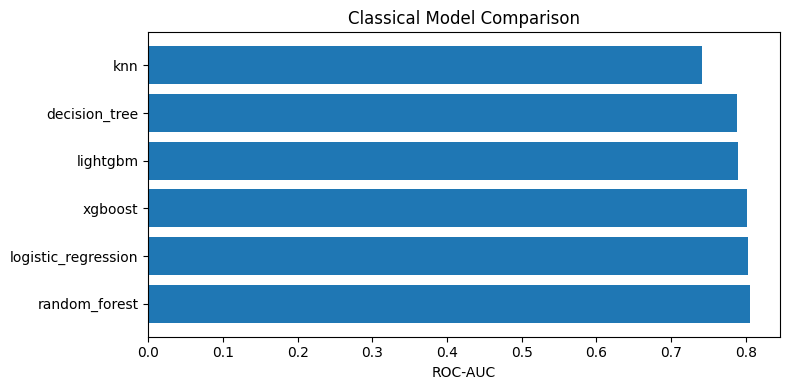

In [15]:
import matplotlib.pyplot as plt

trained = log[log['status'] == 'trained'].sort_values('roc_auc', ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(trained['model'], trained['roc_auc'])
ax.set_xlabel('ROC-AUC')
ax.set_title('Classical Model Comparison')
plt.tight_layout()
plt.show()

In [16]:
import os
print("Current working directory:", os.getcwd())
print("Does the file exist at expected relative path?", os.path.exists('../data/raw/online_retail_II.xlsx'))
print("Does the file exist at project-root-relative path?", os.path.exists('data/raw/online_retail_II.xlsx'))

Current working directory: /home/ionicx/Vantara-churning-prediction-model
Does the file exist at expected relative path? False
Does the file exist at project-root-relative path? True


Exception ignored in: <function ResourceTracker.__del__ at 0x7ff559430180>
Traceback (most recent call last):
  File "/home/ionicx/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/ionicx/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/ionicx/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7fbc8c300180>
Traceback (most recent call last):
  File "/home/ionicx/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/ionicx/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/ionicx/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessErr